# ***SITUACION A ANALIZAR***

Se desea analizar la influencia que tiene la inversion en Educación en Colombia, en lo relativo con el bienestar socio-economico de los Colombianos del departamento de Antioquia y Cundinamarca.

## ***SET DE DATOS PORCENTAJE DE INVERSION ANUAL***

El set de datos es obtenido desde la pagina WEB: https://datosmacro.expansion.com/estado/gasto/colombia, donde cada registro contiene 7 caracteristicas.

### **1 Recolección de datos**


#### **Librerias**

In [1]:
# Importar librerias
import pandas as pd
import numpy as np

#### **1.1 Cargar los Datos**

In [3]:
df_colombia_inversion_original = pd.read_html('https://datosmacro.expansion.com/estado/gasto/colombia')
df_datos_inversion = pd.DataFrame(df_colombia_inversion_original[0])

### **2 Estructura general del DataFrame**

### **2.1 Ver las primeras y últimas filas**
  Sirve para ver una muestra de los datos y entender su estructura.

In [5]:
df_datos_inversion.head()  # Muestra las primeras 5 filas (por defecto muestra 5)

,Fecha,G. Público (M.€),Gasto público (M.$),Gasto Educación (%Gto Pub),G. Salud (%G. Público Total),Gasto Defensa (%Gto Pub),Gasto público (%PIB),Gasto público Per Capita,Gasto público Per Capita.1
0,2023,"117.786,1","127.395,1",NaN,"15,42%","8,31%","35,04%",2.256 €,2.440 $
1,2022,"111.192,4","117.183,1",NaN,"15,72%","8,26%","33,93%",2.151 €,2.267 $
2,2021,"92.316,9","109.259,5","11,55%","19,08%","9,31%","34,30%",1.806 €,2.137 $
3,2020,"79.454,2","90.679,6","15,69%","18,51%","10,54%","33,54%",1.576 €,1.799 $
4,2019,"94.870,5","106.216,8","13,72%","16,53%","9,57%","32,88%",1.921 €,2.150 $


In [6]:
df_datos_inversion.tail()  # Muestra las últimas 5 filas

,Fecha,G. Público (M.€),Gasto público (M.$),Gasto Educación (%Gto Pub),G. Salud (%G. Público Total),Gasto Defensa (%Gto Pub),Gasto público (%PIB),Gasto público Per Capita,Gasto público Per Capita.1
37,1986,NaN,"6.891,3",NaN,NaN,NaN,"14,17%",NaN,226 $
38,1985,NaN,"7.136,5","16,41%",NaN,NaN,"14,70%",NaN,239 $
39,1984,NaN,"8.151,4","18,09%",NaN,NaN,"15,31%",NaN,271 $
40,1983,NaN,"8.120,9",NaN,NaN,NaN,"15,07%",NaN,275 $
41,1982,NaN,"8.164,0",NaN,NaN,NaN,"15,06%",NaN,283 $


### **2.2 Dimensión del DataFrame**
  Nos dice cuántas filas y columnas tiene.

In [7]:
df_datos_inversion.shape

(42, 9)

### **2.3 Nombres de las Columnas e Información Resumen**
  Ayuda a conocer cómo están nombradas las columnas.

In [8]:
columnas = df_datos_inversion.columns

for i in columnas:
  print(i)

Fecha
G. Público (M.€)
Gasto público (M.$)
Gasto Educación (%Gto Pub)
G. Salud (%G. Público Total)
Gasto Defensa (%Gto Pub)
Gasto público (%PIB)
Gasto público Per Capita
Gasto público Per Capita.1


Información General sobre los Datos

In [9]:
df_datos_inversion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Fecha                         42 non-null     int64 
 1   G. Público (M.€)              25 non-null     object
 2   Gasto público (M.$)           42 non-null     object
 3   Gasto Educación (%Gto Pub)    27 non-null     object
 4   G. Salud (%G. Público Total)  29 non-null     object
 5   Gasto Defensa (%Gto Pub)      36 non-null     object
 6   Gasto público (%PIB)          42 non-null     object
 7   Gasto público Per Capita      25 non-null     object
 8   Gasto público Per Capita.1    42 non-null     object
dtypes: int64(1), object(8)
memory usage: 3.1+ KB


In [10]:
df_datos_inversion.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Fecha,42.0,NaN,NaN,NaN,2002.5,12.267844,1982.0,1992.25,2002.5,2012.75,2023.0
G. Público (M.€),25,25,"117.786,1",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gasto público (M.$),42,42,"127.395,1",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gasto Educación (%Gto Pub),27,27,"11,55%",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G. Salud (%G. Público Total),29,27,"17,04%",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gasto Defensa (%Gto Pub),36,35,"9,94%",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gasto público (%PIB),42,42,"35,04%",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gasto público Per Capita,25,25,2.256 €,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gasto público Per Capita.1,42,41,239 $,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **3 Data Cleaning**

Descripción:  
Datos desaparecidos antes de tratar los datos faltantes, es importante determinar su prevalencia y su aleatoriedad, ya que pueden implicar una
reducción del tamaño de la muestra.

También hay que asegurarse que la gestión de los datos desaparecidos
no esté sesgada o esconda una verdad incómoda.

Se realiza un primer analisis de la información, donde encontramos que hay algunas registros sin información en algunas columnas (Null), se identifica que los tipos de datos de estas columnas son de tipo Object, lo cual no permite realizar un buen analisis de los datos estadisticos.

El número de columnas que tiene el dataset, se reducido a solo aquellas columnas que veamos relevantes para el analisis, eliminando el resto.

Por lo cual en la limpieza de datos estara centrado en hallar:
1. Hallar el numero de datos null y realizar su conversion a un valor numerico como cero (0).
2. Convertir la información del tipo de dato Object a Númerico, quitando Caracteres especiales.
3. Analisis e Eliminación de columnas no relevantes.


#### **Librerias**

In [11]:
# Importar librerias uso analisis de datos
import pandas as pd
import numpy as np

# Importar librerias graficos
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore') # Para evitar los molestos avisos.

#### **Cargar los Datos**

In [12]:
df_colombia_inversion_original = pd.read_html('https://datosmacro.expansion.com/estado/gasto/colombia')
df_datos_inversion = pd.DataFrame(df_colombia_inversion_original[0])

#### **3.1 Identificación y Manejo Valores Nulos**

In [13]:
nan_counts = df_datos_inversion.isna().sum()
nan_counts.sort_values(ascending = False)

,0
G. Público (M.€),17
Gasto público Per Capita,17
Gasto Educación (%Gto Pub),15
G. Salud (%G. Público Total),13
Gasto Defensa (%Gto Pub),6
Fecha,0
Gasto público (M.$),0
Gasto público (%PIB),0
Gasto público Per Capita.1,0


In [14]:
df_datos_inversion.isnull().sum().sort_values(ascending = False)

,0
G. Público (M.€),17
Gasto público Per Capita,17
Gasto Educación (%Gto Pub),15
G. Salud (%G. Público Total),13
Gasto Defensa (%Gto Pub),6
Fecha,0
Gasto público (M.$),0
Gasto público (%PIB),0
Gasto público Per Capita.1,0


In [15]:
total = df_datos_inversion.isnull().sum().sort_values(ascending = False)
percent = (df_datos_inversion.isnull().sum() / df_datos_inversion.isnull().count()).sort_values(ascending = False)
missing_data = pd.concat([total, percent], axis = 1, keys = ['Total', 'Percent'])
missing_data.head(20)

#otra manera
#por=df_datos_inversion.isna().sum()/df_datos_inversion.shape[0]*100
#por.sort_values(ascending = False)

,Total,Percent
G. Público (M.€),17,0.404762
Gasto público Per Capita,17,0.404762
Gasto Educación (%Gto Pub),15,0.357143
G. Salud (%G. Público Total),13,0.309524
Gasto Defensa (%Gto Pub),6,0.142857
Fecha,0,0.000000
Gasto público (M.$),0,0.000000
Gasto público (%PIB),0,0.000000
Gasto público Per Capita.1,0,0.000000


<Axes: >

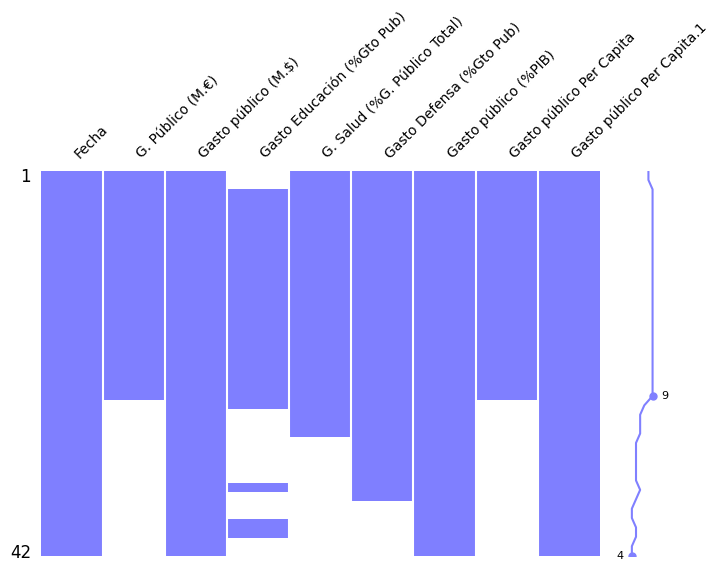

In [16]:
import missingno as msno
msno.matrix(df_datos_inversion, figsize=(8, 5), fontsize=10, color=(0.5, 0.5, 1))

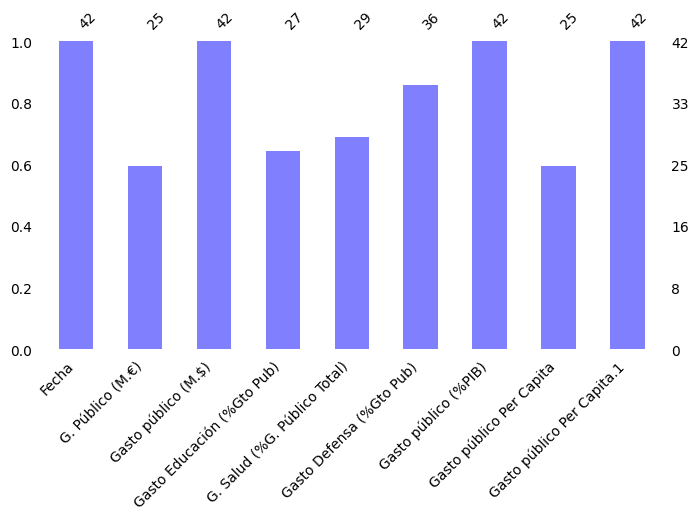

In [17]:
import missingno as msno
msno.bar(df_datos_inversion, figsize=(8, 4), fontsize=10, color=(0.5, 0.5, 1))

s = pd.Series([np.nan, 1, 2, np.nan, 3])
s = s.fillna(method='ffill')

#### **3.1.1 Reemplazar Nulls X 0**

In [18]:
df_datos_inversion=df_datos_inversion.replace('NaN',0)
df_datos_inversion=df_datos_inversion.replace(np.nan,0)

nan_counts = df_datos_inversion.isna().sum()
nan_counts

,0
Fecha,0
G. Público (M.€),0
Gasto público (M.$),0
Gasto Educación (%Gto Pub),0
G. Salud (%G. Público Total),0
Gasto Defensa (%Gto Pub),0
Gasto público (%PIB),0
Gasto público Per Capita,0
Gasto público Per Capita.1,0


<Axes: >

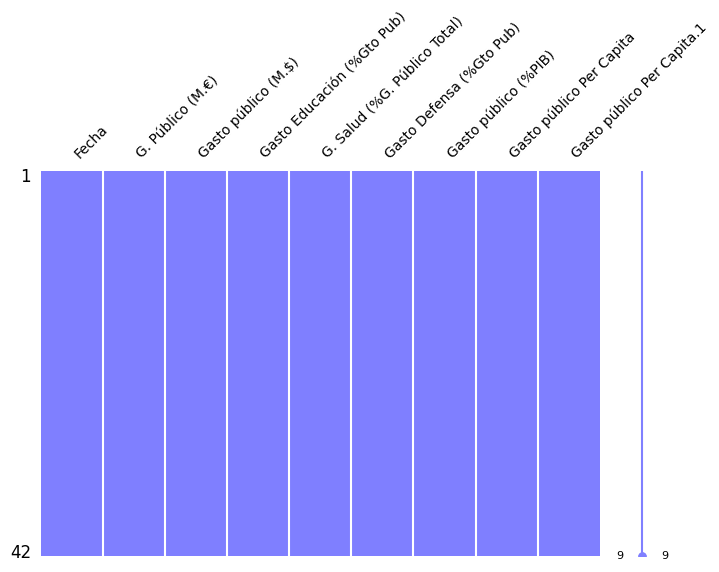

In [19]:
import missingno as msno
msno.matrix(df_datos_inversion, figsize=(8, 5), fontsize=10, color=(0.5, 0.5, 1))

#### **3.2 Funciones Cambiar tipo de datos, limpieza de caracteres**

In [20]:
# Funcion para cambiar quitar puntos
import pandas as pd
import numpy as np

def a_numero_decimal_no_cambios(df):

  try:
    df = df.astype(str).str.replace('.', '', regex=False)
    df = df.astype(str).str.replace(',', '.', regex=False).astype(float)
  except ValueError:
        # Manejar casos en que la conversión no es posible
    print(f"No se puede convertir la columna {df} a float.")
        # Puedes optar por dejar la columna como está o aplicar otra estrategia de limpieza
  return df

def a_numero_decimal_quitar_monedas(df):

  df = df.astype(str).str.replace(r'[$,€]', '', regex=True)
  df = df.astype(str).str.replace('.', '', regex=False).astype(float)
  return df

def a_numero_decimal_quitar_porcentaje(df):
  df= df.str.replace('%', '', regex=False)
  df= df.astype(str).str.replace(',', '.', regex=False).astype(float) /100
  df = df.replace('NaN',0.0)
  df = df.replace(np.nan,0.0)
  return df

Ejecución limpieza

In [21]:
df_datos_inversion['G. Público (M.€)'] = a_numero_decimal_no_cambios(df_datos_inversion['G. Público (M.€)'] )
df_datos_inversion['Gasto público (M.$)'] = a_numero_decimal_no_cambios(df_datos_inversion['Gasto público (M.$)'] )

In [22]:
df_datos_inversion['Gasto público Per Capita'] = a_numero_decimal_quitar_monedas(df_datos_inversion['Gasto público Per Capita'] )
df_datos_inversion['Gasto público Per Capita.1'] = a_numero_decimal_quitar_monedas(df_datos_inversion['Gasto público Per Capita.1'] )

In [23]:
df_datos_inversion['Gasto Educación (%Gto Pub)'] = a_numero_decimal_quitar_porcentaje(df_datos_inversion['Gasto Educación (%Gto Pub)'] )
df_datos_inversion['G. Salud (%G. Público Total)'] = a_numero_decimal_quitar_porcentaje(df_datos_inversion['G. Salud (%G. Público Total)'] )
df_datos_inversion['Gasto Defensa (%Gto Pub)'] = a_numero_decimal_quitar_porcentaje(df_datos_inversion['Gasto Defensa (%Gto Pub)'] )
df_datos_inversion['Gasto público (%PIB)'] = a_numero_decimal_quitar_porcentaje(df_datos_inversion['Gasto público (%PIB)'] )

In [24]:
#Ver datos
df_datos_inversion.head()

,Fecha,G. Público (M.€),Gasto público (M.$),Gasto Educación (%Gto Pub),G. Salud (%G. Público Total),Gasto Defensa (%Gto Pub),Gasto público (%PIB),Gasto público Per Capita,Gasto público Per Capita.1
0,2023,117786.1,127395.1,0.0000,0.1542,0.0831,0.3504,2256.0,2440.0
1,2022,111192.4,117183.1,0.0000,0.1572,0.0826,0.3393,2151.0,2267.0
2,2021,92316.9,109259.5,0.1155,0.1908,0.0931,0.3430,1806.0,2137.0
3,2020,79454.2,90679.6,0.1569,0.1851,0.1054,0.3354,1576.0,1799.0
4,2019,94870.5,106216.8,0.1372,0.1653,0.0957,0.3288,1921.0,2150.0


#### **3.3. Detección y manejo de Valores Duplicados**

#### **3.3.1 Contar Valores Duplicados**

Se buscan registros repetidos que puedan sesgar el análisis.

In [25]:
duplicados = df_datos_inversion.duplicated().sum()
print(duplicados)

#df_datos_inversion.duplicated()
#df_datos_inversion.duplicated(keep='last')
#df_datos_inversion.duplicated(keep=False)

0


#### **3.4. Valores Unicos**

#### **3.4.1. Cantidad valores Unicos por columna**

In [26]:
#Contar Valores Únicos en una Columna

#df_datos_inversion["Fecha"].nunique()
mayor=0
espacio=" "

for i in columnas:
  if len(i) > mayor:
    mayor = len(i)

print(f"Columna {espacio*(mayor-7)} Cant. valores Unicos")

for i in columnas:
  veces = mayor - len(i)
  print(f"{i} {espacio*veces} {df_datos_inversion[i].nunique()}")

Columna                       Cant. valores Unicos
Fecha                         42
G. Público (M.€)              26
Gasto público (M.$)           42
Gasto Educación (%Gto Pub)    28
G. Salud (%G. Público Total)  28
Gasto Defensa (%Gto Pub)      36
Gasto público (%PIB)          42
Gasto público Per Capita      26
Gasto público Per Capita.1    41


#### **3.4.2. Valores Unicos por columna**

In [27]:
for i in columnas:
  print(i)
  print(pd.unique(df_datos_inversion[i]))

Fecha
[2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011 2010
 2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 1996
 1995 1994 1993 1992 1991 1990 1989 1988 1987 1986 1985 1984 1983 1982]
G. Público (M.€)
[117786.1 111192.4  92316.9  79454.2  94870.5  98012.1  80978.4  76629.4
  82727.8  89687.3  86302.6  83885.6  72767.7  65535.9  51580.9  46879.7
  42373.5  36646.4  30282.6  24918.2  23294.2  28912.6  29964.4  28542.9
  27307.3      0. ]
Gasto público (M.$)
[127395.1 117183.1 109259.5  90679.6 106216.8 115800.3  91447.5  84798.
  91796.8 119180.4 114621.8 107843.6 101271.5  86952.9  71866.   68941.
  58078.8  46015.7  37695.1  30981.8  26342.8  27319.7  26837.2  26374.2
  29132.3  30997.2  33358.5  29100.5  24530.8  20083.6  15540.   12619.
  10248.6   9779.3   9745.7   7940.6   7451.4   6891.3   7136.5   8151.4
   8120.9   8164. ]
Gasto Educación (%Gto Pub)
[0.     0.1155 0.1569 0.1372 0.1284 0.1547 0.1493 0.1429 0.1481 0.1626
 0.1502 0.1477 0.1593 0.

#### **3.5. Convertir columna en indice**

In [28]:
# convertir fecha como indice
df_datos_inversion = df_datos_inversion.set_index('Fecha')

#### **3.6. Imputación de datos**

In [29]:
ceros = df_datos_inversion[df_datos_inversion==0].count().sort_values(ascending=False)
ceros

,0
G. Público (M.€),17
Gasto público Per Capita,17
Gasto Educación (%Gto Pub),15
G. Salud (%G. Público Total),13
Gasto Defensa (%Gto Pub),6
Gasto público (M.$),0
Gasto público (%PIB),0
Gasto público Per Capita.1,0


Al analizar la cantidad de datos con valor ceros (anteriormente Null),
identificamos que la imputación no se puede realizar por medio de tecnicas como: Eliminar, Aplicar el promedio de los datos, Aplicar la mediana, Vecinos mas cerca o algoritmos de regresión. Ya que esto afectara los calculos y analisis posteriores.

Afortunadamente las columnas que necesitamos para nuestro analisis son: "Fecha" y "Gasto Educación (%Gto Pub)".

"Fecha" no tiene datos en 0, en cambio la columna  "Gasto Educación (%Gto Pub)" tiene 15 campos en 0.

In [30]:
df= df_datos_inversion.loc[df_datos_inversion['Gasto Educación (%Gto Pub)']==0]
df

,G. Público (M.€),Gasto público (M.$),Gasto Educación (%Gto Pub),G. Salud (%G. Público Total),Gasto Defensa (%Gto Pub),Gasto público (%PIB),Gasto público Per Capita,Gasto público Per Capita.1
Fecha,,,,,,,,
2023,117786.1,127395.1,0.0,0.1542,0.0831,0.3504,2256.0,2440.0
2022,111192.4,117183.1,0.0,0.1572,0.0826,0.3393,2151.0,2267.0
1997,0.0,33358.5,0.0,0.2213,0.0896,0.2618,0.0,889.0
1996,0.0,29100.5,0.0,0.2036,0.1484,0.2507,0.0,786.0
1995,0.0,24530.8,0.0,0.1721,0.1068,0.2220,0.0,673.0
1994,0.0,20083.6,0.0,0.0000,0.1020,0.2057,0.0,561.0
1993,0.0,15540.0,0.0,0.0000,0.1080,0.2000,0.0,442.0
1992,0.0,12619.0,0.0,0.0000,0.0975,0.1841,0.0,366.0
1991,0.0,10248.6,0.0,0.0000,0.0898,0.1769,0.0,303.0


De estos 15 datos, la información que nos interesa son los años superiores a 2000, los cuales solo son dos años (2022, 2023).

In [31]:
df= df_datos_inversion.loc[df_datos_inversion['Gasto Educación (%Gto Pub)']==0]
df[df.index >= 2000]

,G. Público (M.€),Gasto público (M.$),Gasto Educación (%Gto Pub),G. Salud (%G. Público Total),Gasto Defensa (%Gto Pub),Gasto público (%PIB),Gasto público Per Capita,Gasto público Per Capita.1
Fecha,,,,,,,,
2023,117786.1,127395.1,0.0,0.1542,0.0831,0.3504,2256.0,2440.0
2022,111192.4,117183.1,0.0,0.1572,0.0826,0.3393,2151.0,2267.0


Por tal razón se toma la desición de buscar esta información faltante y actulizarla.

se busca en google usando frases como:
"inversion en educacion en colombia 2023 en euros en porcentaje a lo invertido en lo publico"

Resultados obtenidos:

**2025**, Colombia destinará un presupuesto de $12.7 billones de pesos a la educación superior pública.

**2024**, Colombia destinó un 13,47% de su gasto público a educación, el presupuesto para el sector educativo fue de $70,4 billones.

**2023**, Colombia destinó el 13.5% de su gasto público total a educación, lo que representa un gasto público per cápita de 2256 euros.
Inversión en defensa: 8.31% del gasto público total.
Inversión en salud: 15.42% del gasto público total.

**2022**, Colombia destinó un 11,55% de su gasto público a educación, lo que equivale a 2.151 euros por habitante, y el gasto público per cápita en educación en Colombia fue de 206 euros.
Gasto en defensa: 8,31%.
Gasto en sanidad: 15,42%.

In [32]:
#df_datos_inversion2 = df_datos_inversion.copy()

df_datos_inversion.loc[2023, 'Gasto Educación (%Gto Pub)'] = 0.1350
df_datos_inversion.loc[2022, 'Gasto Educación (%Gto Pub)'] = 0.1150
df_datos_inversion.head()

,G. Público (M.€),Gasto público (M.$),Gasto Educación (%Gto Pub),G. Salud (%G. Público Total),Gasto Defensa (%Gto Pub),Gasto público (%PIB),Gasto público Per Capita,Gasto público Per Capita.1
Fecha,,,,,,,,
2023,117786.1,127395.1,0.1350,0.1542,0.0831,0.3504,2256.0,2440.0
2022,111192.4,117183.1,0.1150,0.1572,0.0826,0.3393,2151.0,2267.0
2021,92316.9,109259.5,0.1155,0.1908,0.0931,0.3430,1806.0,2137.0
2020,79454.2,90679.6,0.1569,0.1851,0.1054,0.3354,1576.0,1799.0
2019,94870.5,106216.8,0.1372,0.1653,0.0957,0.3288,1921.0,2150.0


incluir columnas categóricas:

### **4. Análisis de distribución y estadístico**

In [33]:
for i in df_datos_inversion.columns:
  print(df_datos_inversion[i].describe())
  print('\n')

count        42.000000
mean      38163.085714
std       39284.333522
min           0.000000
25%           0.000000
50%       28727.750000
75%       78748.000000
max      117786.100000
Name: G. Público (M.€), dtype: float64


count        42.000000
mean      51521.209524
std       41504.669487
min        6891.300000
25%       13349.250000
50%       30989.500000
75%       91255.525000
max      127395.100000
Name: Gasto público (M.$), dtype: float64


count    42.000000
mean      0.100921
std       0.069583
min       0.000000
25%       0.000000
50%       0.136450
75%       0.153900
max       0.180900
Name: Gasto Educación (%Gto Pub), dtype: float64


count    42.000000
mean      0.118833
std       0.082311
min       0.000000
25%       0.000000
50%       0.159100
75%       0.169875
max       0.226900
Name: G. Salud (%G. Público Total), dtype: float64


count    42.000000
mean      0.092452
std       0.040763
min       0.000000
25%       0.089650
50%       0.103900
75%       0.115625
max   

In [35]:
df_datos_inversion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 2023 to 1982
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   G. Público (M.€)              42 non-null     float64
 1   Gasto público (M.$)           42 non-null     float64
 2   Gasto Educación (%Gto Pub)    42 non-null     float64
 3   G. Salud (%G. Público Total)  42 non-null     float64
 4   Gasto Defensa (%Gto Pub)      42 non-null     float64
 5   Gasto público (%PIB)          42 non-null     float64
 6   Gasto público Per Capita      42 non-null     float64
 7   Gasto público Per Capita.1    42 non-null     float64
dtypes: float64(8)
memory usage: 4.0 KB


#### **4.1 Distribución de los Datos**

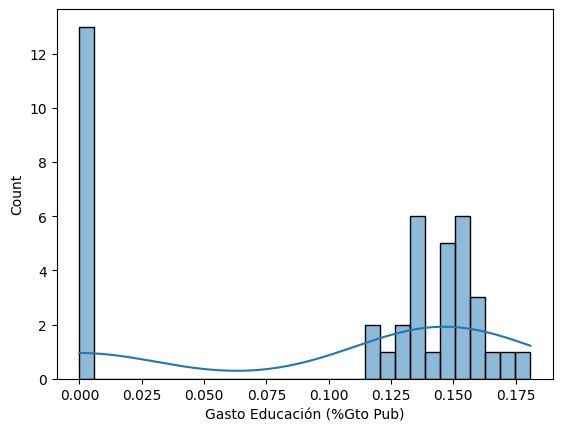

In [36]:
#Se estudia cómo se distribuyen los datos.
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_datos_inversion["Gasto Educación (%Gto Pub)"], bins=30, kde=True)
plt.show()

#### **4.2 Graficos**

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

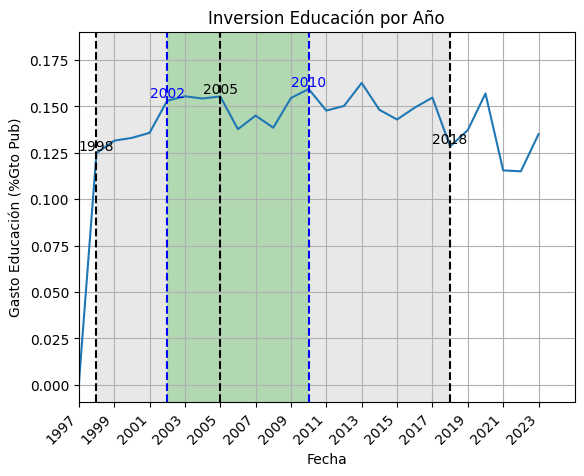

In [38]:
# Inversion en educacion atravez del tiempo

colors = ['blue', 'black']  # Define the two colors
color_index = 1
plt.plot(df_datos_inversion.index, df_datos_inversion['Gasto Educación (%Gto Pub)'])
plt.xlabel('Fecha')
plt.ylabel('Gasto Educación (%Gto Pub)')
plt.title('Inversion Educación por Año')
plt.grid(True)

   # Ajustar el espaciado de las etiquetas del eje x
plt.xticks(df_datos_inversion.index[0::2], rotation=45, ha='right') # Mostrar cada dos años

   # Resaltar los años 2005 y 2018
for year in [1998, 2002, 2005, 2010, 2018]:
    if year in df_datos_inversion.index:  # Asegurarse de que el año esté en el índice
        plt.axvline(x=year, color=colors[color_index], linestyle='--')
        plt.text(year, df_datos_inversion.loc[year, 'Gasto Educación (%Gto Pub)'],
                str(year), color=colors[color_index], ha='center', va='bottom')

        color_index = 1 - color_index

plt.axvspan(1998, 2002, facecolor='lightgray', alpha=0.5)
plt.axvspan(2002, 2010, facecolor='green', alpha=0.3)
plt.axvspan(2010, 2018, facecolor='lightgray', alpha=0.5)

plt.xlim(left=1997)
plt.show()

Pastrana  1998 - 2002                   
Uribe     2002 - 2010                   
Santos    2010 - 2018                   
Duque     2018 - 2022

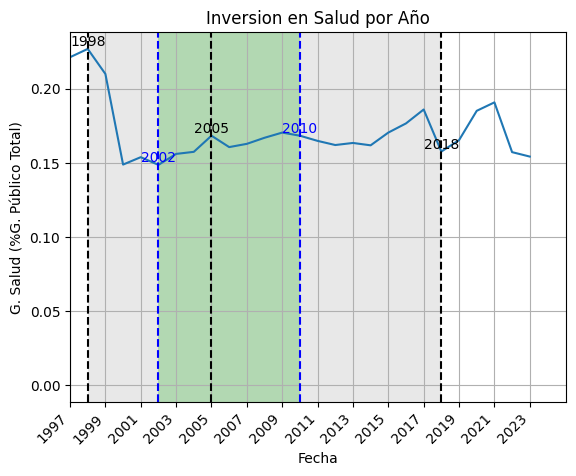

In [39]:
# Inversion en salud atravez del tiempo

colors = ['blue', 'black']  # Define the two colors
color_index = 1
plt.plot(df_datos_inversion.index, df_datos_inversion['G. Salud (%G. Público Total)'])
plt.xlabel('Fecha')
plt.ylabel('G. Salud (%G. Público Total)')
plt.title('Inversion en Salud por Año')
plt.grid(True)

   # Ajustar el espaciado de las etiquetas del eje x
plt.xticks(df_datos_inversion.index[0::2], rotation=45, ha='right') # Mostrar cada dos años


   # Resaltar los años 2005 y 2018
for year in [1998, 2002, 2005, 2010, 2018]:
    if year in df_datos_inversion.index:  # Asegurarse de que el año esté en el índice
        plt.axvline(x=year, color=colors[color_index], linestyle='--')
        plt.text(year, df_datos_inversion.loc[year, 'G. Salud (%G. Público Total)'],
                str(year), color=colors[color_index], ha='center', va='bottom')

        color_index = 1 - color_index

plt.axvspan(1998, 2002, facecolor='lightgray', alpha=0.5)
plt.axvspan(2002, 2010, facecolor='green', alpha=0.3)
plt.axvspan(2010, 2018, facecolor='lightgray', alpha=0.5)

plt.xlim(left=1997)
plt.show()

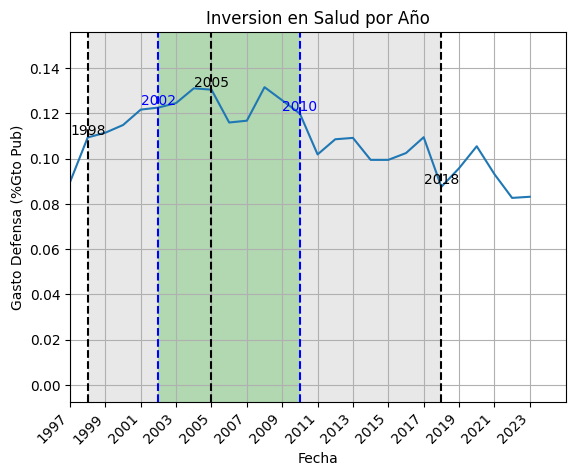

In [40]:
# Inversion en seguridad atravez del tiempo

colors = ['blue', 'black']  # Define the two colors
color_index = 1
plt.plot(df_datos_inversion.index, df_datos_inversion['Gasto Defensa (%Gto Pub)'])
plt.xlabel('Fecha')
plt.ylabel('Gasto Defensa (%Gto Pub)')
plt.title('Inversion en Salud por Año')
plt.grid(True)

   # Ajustar el espaciado de las etiquetas del eje x
plt.xticks(df_datos_inversion.index[0::2], rotation=45, ha='right') # Mostrar cada dos años

   # Resaltar los años 2005 y 2018
for year in [1998, 2002, 2005, 2010, 2018]:
    if year in df_datos_inversion.index:  # Asegurarse de que el año esté en el índice
        plt.axvline(x=year, color=colors[color_index], linestyle='--')
        plt.text(year, df_datos_inversion.loc[year, 'Gasto Defensa (%Gto Pub)'],
                str(year), color=colors[color_index], ha='center', va='bottom')

        color_index = 1 - color_index

plt.axvspan(1998, 2002, facecolor='lightgray', alpha=0.5)
plt.axvspan(2002, 2010, facecolor='green', alpha=0.3)
plt.axvspan(2010, 2018, facecolor='lightgray', alpha=0.5)

plt.xlim(left=1997)
plt.show()

### **5 EXPORTAR**

In [41]:
df_datos_inversion.to_csv('Inversiones.csv', index=True)